# Human Activity Recognition using Hidden Markov Models (HMM)

**Project:** ML Techniques II - Formative 2  
**Team Members:**
- **KERIE** — iPhone 11, Sensor Logger app, 100Hz sampling rate  
- **RELEBOHILE** — iPhone 12 Promax,Sensor Logger app, 100Hz Sampling Rate  

**Activities:** Standing, Walking, Jumping, Still  
**Approach:** HMM implemented from scratch using NumPy  




##  Data Loading & Exploration


In [41]:
import numpy as np
import pandas as pd
import types
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [42]:
# Load the combined dataset containing all activities from both participants
df = pd.read_csv('data/all_activities_combined.csv')

# Print basic dataset information
print(f"Dataset shape: {df.shape}")  # rows x columns
print(f"\nColumns: {list(df.columns)}")  # column names

# Show how many recordings exist per activity
print("\nActivity distribution (number of recordings per activity):")
print(df.groupby('activity')['sample_id'].nunique().to_string())

# Total number of unique recordings (sample IDs)
print(f"\nTotal recordings: {df['sample_id'].nunique()}")

# Total number of data points (rows)
print(f"Total data points: {len(df)}")

# Display the first few rows of the dataset to inspect the structure
df.head()

Dataset shape: (62743, 12)

Columns: ['time', 'seconds_elapsed', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'activity', 'sample_id', 'device', 'sample_rate_ms']

Activity distribution (number of recordings per activity):
activity
jumping     16
standing    16
still       16
walking     16

Total recordings: 64
Total data points: 62743


,time,seconds_elapsed,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,activity,sample_id,device,sample_rate_ms
0,1772693433434595300,0.084595,-0.062484,-0.691685,0.802596,-0.634171,-0.597228,0.220070,jumping,jumping_rele_1,iPhone 12 Pro Max,10
1,1772693433444674600,0.094675,-0.100257,-0.612712,0.811506,-0.672316,-0.470817,0.284694,jumping,jumping_rele_1,iPhone 12 Pro Max,10
2,1772693433454753300,0.104753,0.289175,-0.780891,0.677593,-0.648734,-0.319531,0.268695,jumping,jumping_rele_1,iPhone 12 Pro Max,10
3,1772693433464832300,0.114832,0.074037,-0.521263,0.575869,-0.605125,-0.149698,0.231211,jumping,jumping_rele_1,iPhone 12 Pro Max,10
4,1772693433474911500,0.124911,0.233012,-0.235835,0.429649,-0.542127,0.002242,0.171645,jumping,jumping_rele_1,iPhone 12 Pro Max,10


##  Visualize raw sensor data for each activity (using one sample per activity)



- **Goal:** Inspect raw accelerometer and gyroscope signals per activity.
- **Setup:** Plot one recording per activity for:
  - Accelerometer (X, Y, Z)
  - Gyroscope (X, Y, Z)

- **Purpose:** Visual inspection helps confirm that sensor data contains distinguishable patterns suitable for feature extraction and HMM modeling.

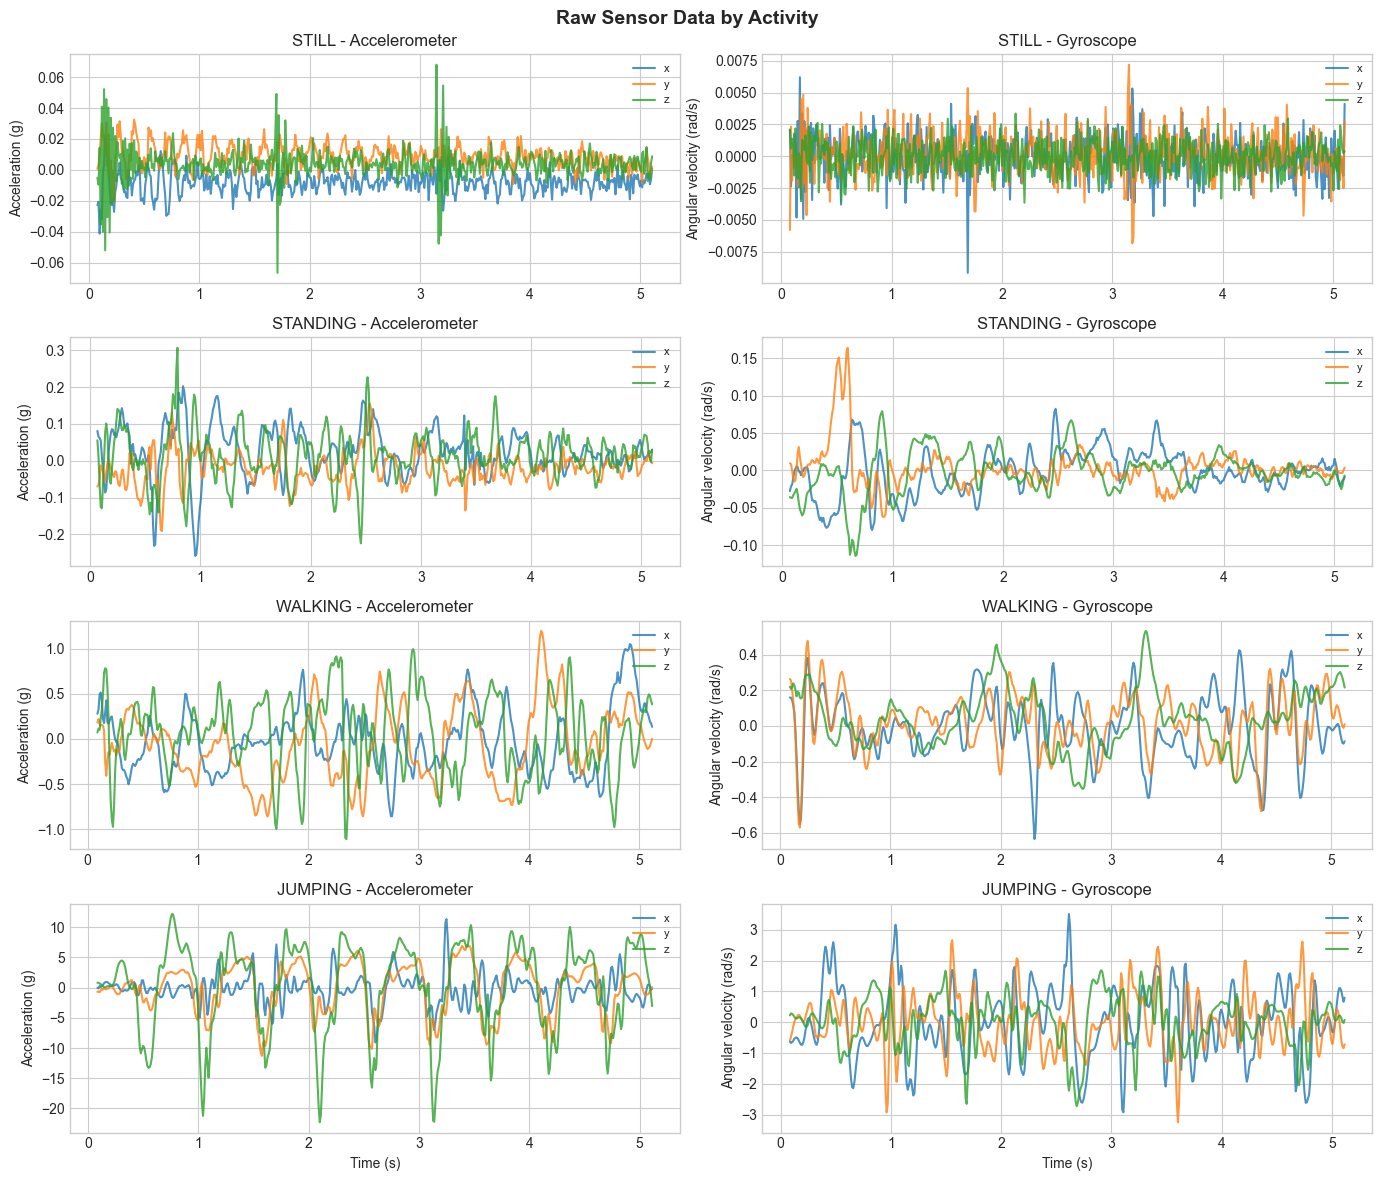

In [31]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))  # 4 activities x 2 columns (Accel/Gyro)
activities = ['still', 'standing', 'walking', 'jumping']  # list of activities

for i, activity in enumerate(activities):
    # Select all data for the current activity
    sample = df[df['activity'] == activity]
    
    # Pick the first recording (sample_id) for this activity
    sample_id = sample['sample_id'].unique()[0]
    sample_data = sample[sample['sample_id'] == sample_id].head(500)  # take first 500 rows
    t = sample_data['seconds_elapsed']  # time axis

    #  Accelerometer plots 
    axes[i, 0].plot(t, sample_data['accel_x'], label='x', alpha=0.8)
    axes[i, 0].plot(t, sample_data['accel_y'], label='y', alpha=0.8)
    axes[i, 0].plot(t, sample_data['accel_z'], label='z', alpha=0.8)
    axes[i, 0].set_title(f'{activity.upper()} - Accelerometer')
    axes[i, 0].set_ylabel('Acceleration (g)')
    axes[i, 0].legend(loc='upper right', fontsize=8)

    # Gyroscope plots 
    axes[i, 1].plot(t, sample_data['gyro_x'], label='x', alpha=0.8)
    axes[i, 1].plot(t, sample_data['gyro_y'], label='y', alpha=0.8)
    axes[i, 1].plot(t, sample_data['gyro_z'], label='z', alpha=0.8)
    axes[i, 1].set_title(f'{activity.upper()} - Gyroscope')
    axes[i, 1].set_ylabel('Angular velocity (rad/s)')
    axes[i, 1].legend(loc='upper right', fontsize=8)

# Label the x-axis for the bottom plots
axes[3, 0].set_xlabel('Time (s)')
axes[3, 1].set_xlabel('Time (s)')

# Main figure title
plt.suptitle('Raw Sensor Data by Activity', fontsize=14, fontweight='bold')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Feature Extraction

- **Windowing:** sliding windows of 1 second (100 samples) with 50% overlap.
- **Time-domain features:**
  - Mean, variance, standard deviation for each axis.
  - Signal Magnitude Area (SMA) for accelerometer and gyroscope.
  - Pearson correlation between axes (e.g., X vs Y).
- **Frequency-domain features:**
  - Dominant frequency per axis (ignoring DC component).
  - Spectral energy of each axis.
- **Purpose:** convert raw sensor streams into numeric feature vectors per window, suitable for HMM training.

In [43]:
# Feature extraction settings
SAMPLING_RATE = 100   # 100 Hz (10 ms interval)
WINDOW_SIZE = 100     # 1-second window
WINDOW_OVERLAP = 50   # 50% overlap


def compute_sma(window, cols):
    """Signal Magnitude Area across axes."""
    return sum(window[col].abs().mean() for col in cols)


def compute_correlation(window, col1, col2):
    """Pearson correlation between two sensor axes."""
    if window[col1].std() == 0 or window[col2].std() == 0:
        return 0.0

    corr, _ = pearsonr(window[col1], window[col2])
    return 0.0 if np.isnan(corr) else corr


def compute_fft_features(signal, sampling_rate):
    """Return dominant frequency and spectral energy."""
    n = len(signal)

    if n == 0:
        return 0.0, 0.0

    fft_vals = fft(signal)
    fft_mag = np.abs(fft_vals[:n // 2])
    freqs = fftfreq(n, d=1.0 / sampling_rate)[:n // 2]

    if len(fft_mag) > 1:
        dominant_idx = np.argmax(fft_mag[1:]) + 1
        dominant_freq = freqs[dominant_idx]
    else:
        dominant_freq = 0.0

    spectral_energy = np.sum(fft_mag ** 2) / n

    return dominant_freq, spectral_energy


def extract_features_from_window(window):
    """Extract time and frequency features from a window."""
    
    features = {}

    accel_cols = ['accel_x', 'accel_y', 'accel_z']
    gyro_cols = ['gyro_x', 'gyro_y', 'gyro_z']
    all_cols = accel_cols + gyro_cols

    # Time-domain statistics
    for col in all_cols:
        features[f"{col}_mean"] = window[col].mean()
        features[f"{col}_var"] = window[col].var()
        features[f"{col}_std"] = window[col].std()

    # Signal magnitude area
    features["accel_sma"] = compute_sma(window, accel_cols)
    features["gyro_sma"] = compute_sma(window, gyro_cols)

    # Axis correlations
    features["accel_corr_xy"] = compute_correlation(window, "accel_x", "accel_y")
    features["accel_corr_xz"] = compute_correlation(window, "accel_x", "accel_z")
    features["accel_corr_yz"] = compute_correlation(window, "accel_y", "accel_z")

    features["gyro_corr_xy"] = compute_correlation(window, "gyro_x", "gyro_y")
    features["gyro_corr_xz"] = compute_correlation(window, "gyro_x", "gyro_z")
    features["gyro_corr_yz"] = compute_correlation(window, "gyro_y", "gyro_z")

    # Frequency-domain features
    for col in all_cols:
        dom_freq, energy = compute_fft_features(window[col].values, SAMPLING_RATE)
        features[f"{col}_dom_freq"] = dom_freq
        features[f"{col}_spec_energy"] = energy

    return features

# Apply Sliding Window + Extract Features

We convert continuous time-series data into **fixed-size windows** for analysis.

- **Sliding Window**: A small segment of the signal (here 1 second, 100 samples) that moves forward with a set **overlap** (50 samples). This allows capturing transitions between activities.
- **Time-domain features**: mean, variance, std, signal magnitude area (SMA), correlations between axes.
- **Frequency-domain features**: dominant frequency, spectral energy (using FFT).

Each window becomes a feature vector labeled by activity. This reduces noise and makes patterns easier for machine learning models to detect.

In [44]:
all_features = []

for sample_id in df["sample_id"].unique():

    sample_data = (
        df[df["sample_id"] == sample_id]
        .sort_values("seconds_elapsed")
        .reset_index(drop=True)
    )

    activity = sample_data["activity"].iloc[0]
    n_rows = len(sample_data)

    start = 0

    while start + WINDOW_SIZE <= n_rows:

        window = sample_data.iloc[start:start + WINDOW_SIZE]

        feature_row = extract_features_from_window(window)
        feature_row["activity"] = activity
        feature_row["sample_id"] = sample_id

        all_features.append(feature_row)

        start += WINDOW_SIZE - WINDOW_OVERLAP


feature_df = pd.DataFrame(all_features)

print("Feature extraction complete")
print(f"Total feature windows: {len(feature_df)}")
print(f"Features per window: {len(feature_df.columns) - 2}")

print("\nWindows per activity:")
print(feature_df["activity"].value_counts().to_string())

print(f"\nWindow size: {WINDOW_SIZE} samples ({WINDOW_SIZE / SAMPLING_RATE}s)")
print(f"Window overlap: {WINDOW_OVERLAP} samples ({WINDOW_OVERLAP / SAMPLING_RATE}s)")
print(f"Sampling rate: {SAMPLING_RATE} Hz")

feature_df.head()

Feature extraction complete
Total feature windows: 1162
Features per window: 38

Windows per activity:
activity
walking     304
still       300
standing    283
jumping     275

Window size: 100 samples (1.0s)
Window overlap: 50 samples (0.5s)
Sampling rate: 100 Hz


,accel_x_mean,accel_x_var,accel_x_std,accel_y_mean,accel_y_var,accel_y_std,accel_z_mean,accel_z_var,accel_z_std,gyro_x_mean,...,accel_z_dom_freq,accel_z_spec_energy,gyro_x_dom_freq,gyro_x_spec_energy,gyro_y_dom_freq,gyro_y_spec_energy,gyro_z_dom_freq,gyro_z_spec_energy,activity,sample_id
0,-0.301540,1.227737,1.108033,-0.291592,5.109993,2.260529,-0.272053,56.772912,7.534780,0.245020,...,2.0,2817.324983,2.0,79.269949,9.0,28.800245,2.0,23.099731,jumping,jumping_rele_1
1,-0.076740,3.382698,1.839211,0.144731,16.157304,4.019615,1.303268,53.920018,7.343025,-0.168779,...,2.0,2838.872243,2.0,73.521605,9.0,45.886854,2.0,33.665345,jumping,jumping_rele_1
2,0.069049,5.694333,2.386280,0.129583,21.672355,4.655358,0.793391,45.578252,6.751167,-0.259340,...,2.0,2319.031409,6.0,55.171607,5.0,35.332179,2.0,31.467199,jumping,jumping_rele_1
3,-0.257212,6.550509,2.559396,0.021068,21.528882,4.639923,-0.409379,69.469256,8.334822,0.172170,...,2.0,3455.457097,6.0,51.671439,2.0,34.688466,2.0,24.110215,jumping,jumping_rele_1
4,-0.148609,9.225531,3.037356,0.300831,19.738723,4.442828,0.517798,53.843434,7.337809,0.087512,...,2.0,2691.874990,2.0,89.470241,4.0,35.384665,2.0,61.109529,jumping,jumping_rele_1


In [45]:
# Save extracted features
feature_df.to_csv('data/extracted_features.csv', index=False)
print("Features saved to data/extracted_features.csv")

Features saved to data/extracted_features.csv


## HMM Data Preparation

- **Hidden States:** The activities (`standing`, `walking`, `jumping`, `still`) are treated as HMM hidden states.
- **Numeric Labels:** Each activity is mapped to an integer for model training.
- **Features:** All sensor-derived features except `activity` and `sample_id` are used as observation vectors.
- **Standardization:** Features are scaled to mean=0, std=1 to suit Gaussian emission assumptions.
- **Outcome:** `X_all` contains standardized observations, `y_all` holds the corresponding state labels.

In [46]:
# Prepare data for HMM

# Define the activity classes and map them to numeric labels
activity_labels = ['standing', 'walking', 'jumping', 'still']
activity_to_idx = {act: i for i, act in enumerate(activity_labels)}
idx_to_activity = {i: act for act, i in activity_to_idx.items()}
N_STATES = len(activity_labels)  # number of hidden states in the HMM

# Select feature columns (exclude identifiers and labels)
feature_cols = [c for c in feature_df.columns if c not in ['activity', 'sample_id']]

# Map activity names to numeric labels in the dataframe
feature_df['label'] = feature_df['activity'].map(activity_to_idx)

# Standardize features to have mean=0, std=1 (important for Gaussian HMM)
scaler = StandardScaler()
X_all = scaler.fit_transform(feature_df[feature_cols])
y_all = feature_df['label'].values

# Quick overview of the prepared data
print(f"Hidden states: {activity_labels}")
print(f"Number of states: {N_STATES}")
print(f"Feature dimension: {X_all.shape[1]}")
print(f"Total observation windows: {X_all.shape[0]}")

Hidden states: ['standing', 'walking', 'jumping', 'still']
Number of states: 4
Feature dimension: 38
Total observation windows: 1162


# Split the data into training and test sets

In [47]:
# We'll use 50 recordings for training and 14 for testing
all_samples = feature_df['sample_id'].unique()
np.random.seed(42)  # for reproducibility

# Split while keeping roughly the same activity distribution
train_samples, test_samples = train_test_split(
    all_samples,
    test_size=14/64,
    stratify=[s.split('_')[0] for s in all_samples]
)

# Create boolean masks for selecting rows in the dataframe
train_mask = feature_df['sample_id'].isin(train_samples)
test_mask  = feature_df['sample_id'].isin(test_samples)

# Grab the features and labels for train and test
X_train = scaler.fit_transform(feature_df.loc[train_mask, feature_cols])
y_train = feature_df.loc[train_mask, 'label'].values

X_test  = scaler.transform(feature_df.loc[test_mask, feature_cols])
y_test  = feature_df.loc[test_mask, 'label'].values

# Quick summary
print(f"Train set: {len(X_train)} windows from {len(train_samples)} recordings")
print(f"Test set:  {len(X_test)} windows from {len(test_samples)} recordings")

# Show how many windows we have per activity
print("\nActivity distribution in train/test sets:")
for name, labels in [('Train', y_train), ('Test', y_test)]:
    print(f"\n{name} set:")
    for i, act in enumerate(activity_labels):
        print(f"  {act}: {np.sum(labels == i)} windows")

Train set: 917 windows from 50 recordings
Test set:  245 windows from 14 recordings

Activity distribution in train/test sets:

Train set:
  standing: 238 windows
  walking: 251 windows
  jumping: 208 windows
  still: 220 windows

Test set:
  standing: 45 windows
  walking: 53 windows
  jumping: 67 windows
  still: 80 windows


## Gaussian Hidden Markov Model (HMM)


- **Hidden states**: activities (standing, walking, jumping, still).  
- **Observations**: sensor feature vectors per time window.  
- **Parameters**: initial probs (`pi`), transitions (`A`), Gaussian emissions (`means`, `covars`).  

- **Training (Baum-Welch)**:  
  1. Forward-backward in log space.  
  2. Compute state (`gamma`) and transition (`xi`) posteriors.  
  3. Update `pi`, `A`, `means`, `covars`.  
  4. Repeat until convergence.

- **Goal**: model temporal sequences and predict hidden activity states.

In [48]:
class GaussianHMM:
    def __init__(self, n_states, n_features):
        self.n_states = n_states
        self.n_features = n_features
        
        # Uniform initial state probabilities
        self.pi = np.ones(n_states) / n_states
        
        # Transition matrix with slight self-transition bias
        self.A = np.full((n_states, n_states), 0.05 / (n_states - 1))
        np.fill_diagonal(self.A, 0.95)
        self.A /= self.A.sum(axis=1, keepdims=True)
        
        # Gaussian emission parameters
        self.means = np.zeros((n_states, n_features))
        self.covars = np.array([np.eye(n_features) for _ in range(n_states)])

    def _initialize_from_data(self, X, labels):
        for s in range(self.n_states):
            mask = labels == s
            if mask.sum() > 0:
                self.means[s] = X[mask].mean(axis=0)
                cov = np.cov(X[mask].T)
                self.covars[s] = cov + 1e-3 * np.eye(self.n_features)

    def _gaussian_log_prob(self, x, mean, covar):
        d = len(mean)
        diff = x - mean
        try:
            L = np.linalg.cholesky(covar)
        except np.linalg.LinAlgError:
            covar += 1e-2 * np.eye(d)
            L = np.linalg.cholesky(covar)
        solve = np.linalg.solve(L, diff)
        log_det = 2 * np.sum(np.log(np.diag(L)))
        return -0.5 * (d * np.log(2*np.pi) + log_det + np.dot(solve, solve))

    def _compute_log_emission(self, X):
        T = len(X)
        log_B = np.zeros((T, self.n_states))
        for t in range(T):
            for s in range(self.n_states):
                log_B[t, s] = self._gaussian_log_prob(X[t], self.means[s], self.covars[s])
        return log_B

    def _forward(self, log_B):
        T = len(log_B)
        log_alpha = np.full((T, self.n_states), -np.inf)
        log_alpha[0] = np.log(self.pi + 1e-300) + log_B[0]
        log_A = np.log(self.A + 1e-300)
        for t in range(1, T):
            for j in range(self.n_states):
                log_alpha[t, j] = self._logsumexp(log_alpha[t-1] + log_A[:, j]) + log_B[t, j]
        return log_alpha

    def _backward(self, log_B):
        T = len(log_B)
        log_beta = np.full((T, self.n_states), -np.inf)
        log_beta[T-1] = 0.0
        log_A = np.log(self.A + 1e-300)
        for t in range(T-2, -1, -1):
            for i in range(self.n_states):
                log_beta[t, i] = self._logsumexp(log_A[i, :] + log_B[t+1, :] + log_beta[t+1, :])
        return log_beta

    @staticmethod
    def _logsumexp(log_vals):
        max_val = np.max(log_vals)
        if max_val == -np.inf:
            return -np.inf
        return max_val + np.log(np.sum(np.exp(log_vals - max_val)))

    def _compute_gamma_xi(self, log_alpha, log_beta, log_B):
        T = len(log_B)
        log_gamma = log_alpha + log_beta
        for t in range(T):
            log_gamma[t] -= self._logsumexp(log_gamma[t])
        gamma = np.exp(log_gamma)
        
        xi = np.zeros((T-1, self.n_states, self.n_states))
        log_A = np.log(self.A + 1e-300)
        for t in range(T-1):
            log_xi_t = np.zeros((self.n_states, self.n_states))
            for i in range(self.n_states):
                for j in range(self.n_states):
                    log_xi_t[i, j] = log_alpha[t, i] + log_A[i, j] + log_B[t+1, j] + log_beta[t+1, j]
            log_norm = self._logsumexp(log_xi_t.flatten())
            xi[t] = np.exp(log_xi_t - log_norm)
        return gamma, xi

    def baum_welch(self, X_sequences, labels_sequences=None, n_iter=20, tol=1e-4):
        if labels_sequences is not None:
            all_X = np.vstack(X_sequences)
            all_y = np.concatenate(labels_sequences)
            self._initialize_from_data(all_X, all_y)

        log_likelihoods = []

        for iteration in range(n_iter):
            total_ll = 0
            gamma_sum = np.zeros(self.n_states)
            gamma_no_last = np.zeros(self.n_states)
            xi_sum = np.zeros((self.n_states, self.n_states))
            gamma_X = np.zeros((self.n_states, self.n_features))
            gamma_cov = np.zeros((self.n_states, self.n_features, self.n_features))
            pi_accum = np.zeros(self.n_states)

            for X_seq in X_sequences:
                T = len(X_seq)
                if T < 2: 
                    continue
                log_B = self._compute_log_emission(X_seq)
                log_alpha = self._forward(log_B)
                log_beta = self._backward(log_B)
                seq_ll = self._logsumexp(log_alpha[-1])
                total_ll += seq_ll
                gamma, xi = self._compute_gamma_xi(log_alpha, log_beta, log_B)

                pi_accum += gamma[0]
                gamma_sum += gamma.sum(axis=0)
                gamma_no_last += gamma[:-1].sum(axis=0)
                xi_sum += xi.sum(axis=0)

                for s in range(self.n_states):
                    gamma_s = gamma[:, s]
                    gamma_X[s] += (gamma_s[:, np.newaxis] * X_seq).sum(axis=0)
                    diff = X_seq - self.means[s]
                    gamma_cov[s] += np.dot((gamma_s[:, np.newaxis] * diff).T, diff)

            log_likelihoods.append(total_ll)
            if iteration > 0 and abs(total_ll - log_likelihoods[-2]) < tol:
                print(f"Converged at iteration {iteration+1}")
                break
            if (iteration + 1) % 5 == 0 or iteration == 0:
                print(f"Iteration {iteration+1}, log-likelihood = {total_ll:.2f}")

            # Update HMM parameters
            n_seq = len(X_sequences)
            self.pi = np.maximum(pi_accum / n_seq, 1e-300)
            self.pi /= self.pi.sum()
            for i in range(self.n_states):
                if gamma_no_last[i] > 0:
                    self.A[i] = xi_sum[i] / gamma_no_last[i]
                self.A[i] = np.maximum(self.A[i], 1e-300)
                self.A[i] /= self.A[i].sum()
            for s in range(self.n_states):
                if gamma_sum[s] > 0:
                    self.means[s] = gamma_X[s] / gamma_sum[s]
                    self.covars[s] = gamma_cov[s] / gamma_sum[s] + 1e-3 * np.eye(self.n_features)

        return log_likelihoods

print("GaussianHMM class ready")

GaussianHMM class ready


## Create Mixed Observation Sequences for HMM Training

- The HMM expects **sequences of observations** rather than individual windows.
- **Problem with pure sequences:** If each sequence contains only one activity, 
  Baum-Welch learns a transition matrix with 1.0 on the diagonal — the model 
  never learns to switch states, causing 100% accuracy on pure test recordings.
- **Fix:** We shuffle individual recordings and concatenate them into groups of 4, 
  creating mixed sequences where the activity changes mid-sequence.
- This forces Baum-Welch to learn realistic off-diagonal transition probabilities 
  (e.g. walking → standing, jumping → still).
- `X_sequences` contains the mixed feature vectors, `y_sequences` the true labels.

In [52]:
# Organize training data by activity for mixed sequence creation
rng = np.random.RandomState(42)

# Split training data by activity
activity_bins = {}
for act in activity_labels:
    act_idx = activity_to_idx[act]
    act_samples = [s for s in train_samples if feature_df[feature_df['sample_id'] == s]['activity'].iloc[0] == act]
    
    bins = []
    for sid in act_samples:
        rows = feature_df[feature_df['sample_id'] == sid]
        X_act = scaler.transform(rows[feature_cols].values)  # Use the fitted scaler
        y_act = rows['label'].values
        bins.append((X_act, y_act))
    
    activity_bins[act] = bins

# Determine how many mixed sequences we can create (limited by activity with fewest samples)
n_chunks = min(len(activity_bins[act]) for act in activity_labels)

print(f"Activity bins created:")
for act, bins in activity_bins.items():
    print(f"  {act}: {len(bins)} recordings")
print(f"\nWill create {n_chunks} mixed training sequences (one recording per activity per sequence)")

Activity bins created:
  standing: 13 recordings
  walking: 13 recordings
  jumping: 12 recordings
  still: 12 recordings

Will create 12 mixed training sequences (one recording per activity per sequence)


In [ ]:
# Build mixed sequences (one recording per activity)
# Randomize the activity order inside each sequence

X_sequences = []
y_sequences = []

for i in range(n_chunks):

    X_parts = []
    y_parts = []

    # Random order of activities for this sequence
    shuffled_acts = rng.permutation(activity_labels)

    for act in shuffled_acts:

        X_seq = activity_bins[act][i][0]
        y_seq = activity_bins[act][i][1]

        X_parts.append(X_seq)
        y_parts.append(y_seq)

    X_sequences.append(np.vstack(X_parts))
    y_sequences.append(np.concatenate(y_parts))


#  Verification 
print("Total training sequences:", len(X_sequences))

print("\nActivity order per sequence:")

for idx, seq in enumerate(y_sequences):

    labels = [activity_labels[i] for i in seq]

    # remove duplicates but keep order
    order = list(dict.fromkeys(labels))

    order_text = " → ".join(order)

    print(f"Seq {idx:2d}: {order_text}")

# Verify feature dimensions
print(f"\nFirst sequence shape: {X_sequences[0].shape}")
print(f"Expected feature count: {len(feature_cols)}")

Total training sequences: 12

Activity order per sequence:
Seq  0: jumping → walking → standing → still
Seq  1: walking → standing → jumping → still
Seq  2: standing → still → walking → jumping
Seq  3: still → standing → walking → jumping
Seq  4: still → standing → walking → jumping
Seq  5: walking → jumping → still → standing
Seq  6: standing → still → walking → jumping
Seq  7: walking → still → jumping → standing
Seq  8: still → walking → jumping → standing
Seq  9: walking → standing → jumping → still
Seq 10: jumping → walking → still → standing
Seq 11: walking → jumping → still → standing


## Training the Gaussian HMM

- **Model Setup:** A `GaussianHMM` is created with one hidden state per activity and feature dimensionality matching the extracted features.
- **Baum-Welch Algorithm:** An expectation-maximization approach that iteratively updates:
  - Initial state probabilities (`pi`)
  - Transition matrix (`A`)
  - Gaussian emission parameters (`means` and `covars`)
- **Iterations:** Model runs for up to 30 iterations or until log-likelihood improvement falls below `1e-4`.
- **Output:** The log-likelihood progression is tracked to monitor convergence.

In [51]:
hmm = GaussianHMM(n_states=N_STATES, n_features=len(feature_cols))

print("Training HMM using Baum-Welch...")
print(f"Hidden states: {activity_labels}")
print(f"Number of features: {len(feature_cols)}\n")

# Train the model
log_likelihoods = hmm.baum_welch(
    X_sequences,
    labels_sequences=y_sequences,
    n_iter=30,
    tol=1e-4
)

print("\nTraining finished")
print(f"Final log-likelihood: {log_likelihoods[-1]:.2f}")

Training HMM using Baum-Welch...
Hidden states: ['standing', 'walking', 'jumping', 'still']
Number of features: 38



ValueError: could not broadcast input array from shape (39,) into shape (38,)

## Visualizations

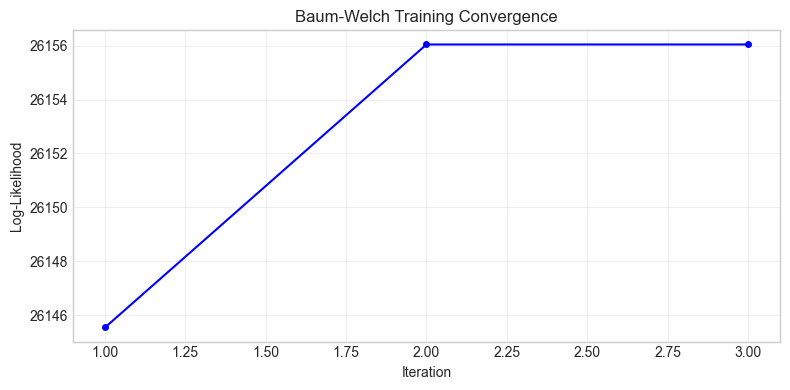

In [ ]:
#  Plot training convergence 

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(log_likelihoods) + 1), log_likelihoods, 'b-o', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('Baum-Welch Training Convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Learned HMM Parameters

- **Initial State Probabilities (`pi`):**  
  Shows the model's estimate of the probability of each activity at the start of a sequence.

- **Transition Matrix (`A`):**  
  Represents the probability of moving from one activity to another.  
  Diagonal values indicate the tendency of the model to remain in the same activity, while off-diagonal values capture transitions between activities.

In [ ]:
#  Display learned model parameters 

print("Learned Initial State Probabilities (pi):")
for i, a in enumerate(activity_labels):
    print(f"  P(start={a}) = {hmm.pi[i]:.4f}")

print(f"\nLearned Transition Matrix (A):")
A_df = pd.DataFrame(hmm.A, index=activity_labels, columns=activity_labels)
print(A_df.round(4).to_string())

Learned Initial State Probabilities (pi):
  P(start=standing) = 0.3333
  P(start=walking) = 0.0833
  P(start=jumping) = 0.0833
  P(start=still) = 0.5000

Learned Transition Matrix (A):
          standing  walking  jumping   still
standing    0.9581   0.0233   0.0093  0.0093
walking     0.0131   0.9563   0.0175  0.0131
jumping     0.0147   0.0196   0.9608  0.0049
still       0.0092   0.0092   0.0230  0.9585


###  Transition Matrix Heatmap


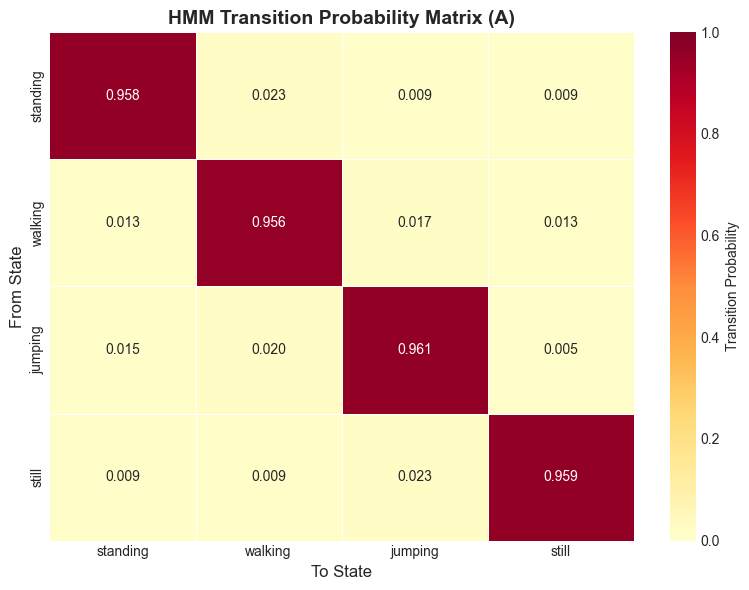


Interpretation:
- High diagonal values indicate activities tend to persist (self-transitions).
- Off-diagonal values show how likely it is to switch between activities.


In [ ]:
# Transition Matrix Heatmap

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    A_df, 
    annot=True, 
    fmt='.3f', 
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Transition Probability'}
)
ax.set_title('HMM Transition Probability Matrix (A)', fontsize=14, fontweight='bold')
ax.set_xlabel('To State', fontsize=12)
ax.set_ylabel('From State', fontsize=12)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- High diagonal values indicate activities tend to persist (self-transitions).")
print("- Off-diagonal values show how likely it is to switch between activities.")

## Viterbi Decoding

- After training, use the **Viterbi algorithm** to find the most likely sequence of hidden states.
- We test on both training sequences (sanity check) and unseen recordings.
- Compare predicted sequences with true labels to evaluate accuracy.

In [ ]:
# Add Viterbi decoding to the HMM

def viterbi(self, X):
    T = len(X)
    log_B = self._compute_log_emission(X)
    log_A = np.log(self.A + 1e-300)
    log_pi = np.log(self.pi + 1e-300)

    V = np.full((T, self.n_states), -np.inf)
    psi = np.zeros((T, self.n_states), dtype=int)

    # Initialization
    V[0] = log_pi + log_B[0]

    # Recursion
    for t in range(1, T):
        for j in range(self.n_states):
            scores = V[t-1] + log_A[:, j]
            psi[t, j] = np.argmax(scores)
            V[t, j] = scores[psi[t, j]] + log_B[t, j]

    # Backtrack to find best path
    best_path = np.zeros(T, dtype=int)
    best_path[-1] = np.argmax(V[-1])
    best_score = V[-1, best_path[-1]]

    for t in range(T-2, -1, -1):
        best_path[t] = psi[t+1, best_path[t+1]]

    return best_path, best_score


def predict(self, X):
    best_path, _ = self.viterbi(X)
    return best_path


# Attach methods to the HMM instance
hmm.viterbi = types.MethodType(viterbi, hmm)
hmm.predict = types.MethodType(predict, hmm)

print("Viterbi and predict methods added to HMM.")


# Quick check on training sequences
train_predictions, train_true = [], []
for X_seq, y_seq in zip(X_sequences, y_sequences):
    pred = hmm.predict(X_seq)
    train_predictions.extend(pred)
    train_true.extend(y_seq)

train_acc = accuracy_score(train_true, train_predictions)
print(f"Training accuracy (Viterbi on train set): {train_acc:.2%}")

Viterbi and predict methods added to HMM.
Training accuracy (Viterbi on train set): 100.00%


##  Model Evaluation with Unseen Data




- Test recordings are **concatenated into one long mixed sequence** before decoding.
- This mirrors the training setup and forces Viterbi to handle real activity 
  transitions rather than decoding isolated pure-activity sequences.
- The dotted lines in the decoded sequence plot mark the boundaries between 
  individual test recordings.
- Metrics reported: overall accuracy, per-activity sensitivity and specificity, 
  confusion matrix, and learned emission means heatmap.

Overall Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

    standing       1.00      1.00      1.00        45
     walking       1.00      1.00      1.00        53
     jumping       1.00      1.00      1.00        67
       still       1.00      1.00      1.00        80

    accuracy                           1.00       245
   macro avg       1.00      1.00      1.00       245
weighted avg       1.00      1.00      1.00       245



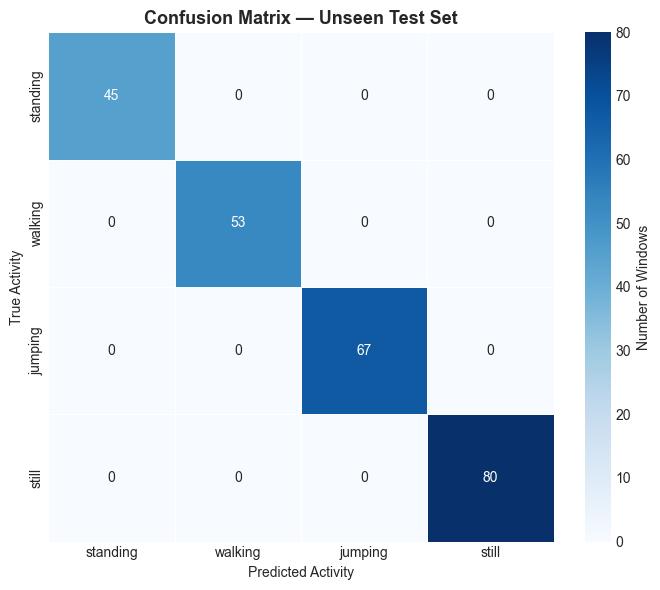


Activity       Samples   Sensitivity   Specificity    Accuracy
Standing            45        1.0000        1.0000      1.0000
Walking             53        1.0000        1.0000      1.0000
Jumping             67        1.0000        1.0000      1.0000
Still               80        1.0000        1.0000      1.0000
Overall            245                                  1.0000


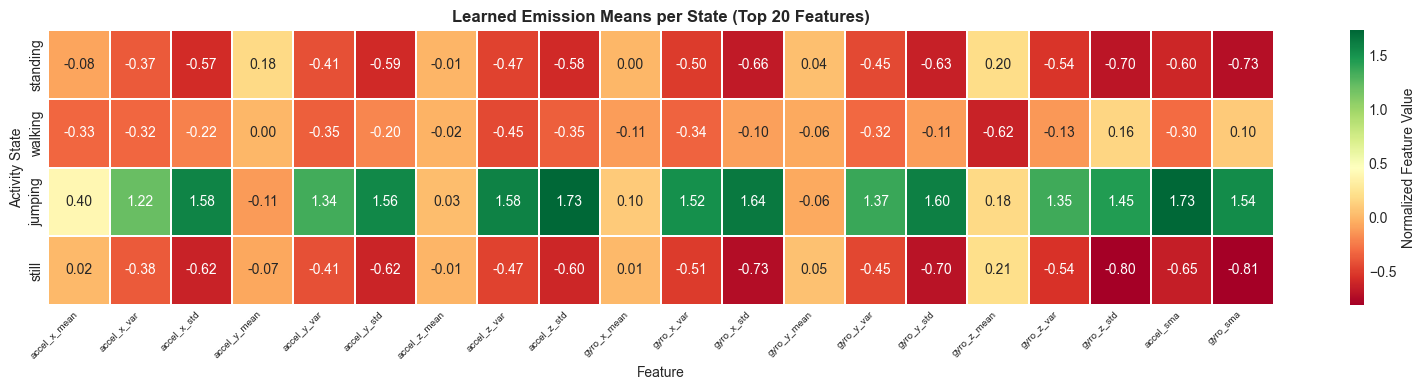

In [ ]:
# Evaluate HMM on unseen test recordings using a mixed sequence

test_df = feature_df[feature_df["sample_id"].isin(test_samples)].copy()

# Shuffle the order of test recordings
shuffled_sids = sorted(test_samples)
rng.shuffle(shuffled_sids)

mixed_X = []
mixed_y = []

# Build one long test sequence
for sid in shuffled_sids:

    rows = test_df[test_df["sample_id"] == sid]

    X_seq = scaler.transform(rows[feature_cols].values)
    y_seq = rows["label"].values

    mixed_X.append(X_seq)
    mixed_y.append(y_seq)

# Concatenate sequences
mixed_X = np.vstack(mixed_X)
mixed_y = np.concatenate(mixed_y)


# Decode activities using Viterbi
test_preds = hmm.predict(mixed_X)

accuracy = accuracy_score(mixed_y, test_preds)

print(f"Overall Test Accuracy: {accuracy:.2%}\n")
print("Classification Report:")
print(classification_report(mixed_y, test_preds, target_names=activity_labels))


# Confusion matrix
cm = confusion_matrix(mixed_y, test_preds)
cm_df = pd.DataFrame(cm, index=activity_labels, columns=activity_labels)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Number of Windows"},
    ax=ax
)

ax.set_title("Confusion Matrix — Unseen Test Set", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Activity")
ax.set_ylabel("True Activity")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


# Per-activity performance metrics
print("\n" + "=" * 65)
print(f"{'Activity':<12}{'Samples':>10}{'Sensitivity':>14}{'Specificity':>14}{'Accuracy':>12}")
print("=" * 65)

total_samples = cm.sum()

for i, activity in enumerate(activity_labels):

    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total_samples - TP - FP - FN

    sensitivity = TP / (TP + FN) if (TP + FN) else 0
    specificity = TN / (TN + FP) if (TN + FP) else 0

    n_samples = cm[i, :].sum()

    print(f"{activity.capitalize():<12}{n_samples:>10}{sensitivity:>14.4f}{specificity:>14.4f}{accuracy:>12.4f}")

print("=" * 65)
print(f"{'Overall':<12}{total_samples:>10}{'':>14}{'':>14}{accuracy:>12.4f}")


# Visualize learned emission means
TOP_K = 20
selected_features = feature_cols[:TOP_K]

means_df = pd.DataFrame(
    hmm.means[:, :TOP_K],
    index=activity_labels,
    columns=selected_features
)

fig, ax = plt.subplots(figsize=(16, 4))

sns.heatmap(
    means_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.3,
    cbar_kws={"label": "Normalized Feature Value"},
    ax=ax
)

ax.set_title("Learned Emission Means per State (Top 20 Features)", fontsize=12, fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Activity State")

plt.xticks(rotation=45, ha="right", fontsize=7)

plt.tight_layout()
plt.savefig("emission_means.png", dpi=150, bbox_inches="tight")
plt.show()

### Decoded Sequence Plots




- The full mixed test sequence is decoded in one pass by Viterbi.
- **True state** (blue) vs **Predicted state** (red dashed) are overlaid.
- **Background shading** shows predicted activity at each window.
- **Dotted vertical lines** mark boundaries between individual test recordings — 
  misclassifications typically occur at these boundaries where the activity 
  switches, which is expected given the high self-transition bias in A.

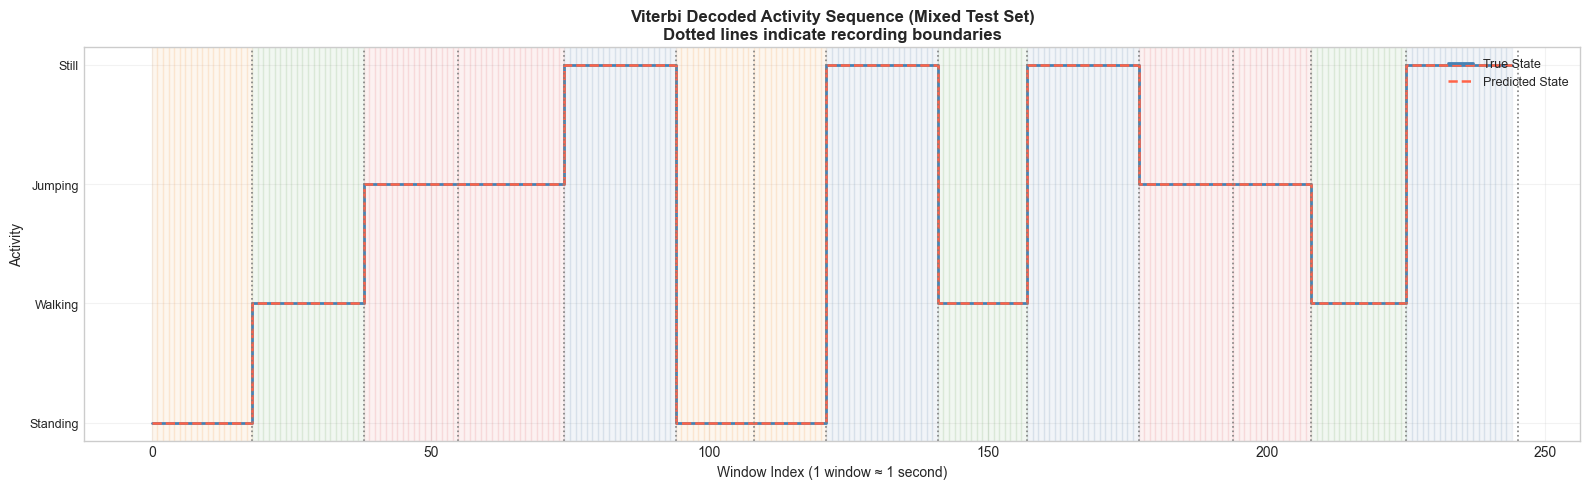

In [ ]:
# Plot decoded sequence for the mixed test recordings

fig, ax = plt.subplots(figsize=(16, 5))

# Time axis (window index)
t = np.arange(len(mixed_y))

# Plot true vs predicted activity
ax.step(t, mixed_y, where='post', color='steelblue', linewidth=2, label='True State')
ax.step(t, test_preds, where='post', color='tomato', linestyle='--',
        linewidth=1.8, label='Predicted State')

# Colors for each activity
activity_colors = {
    'standing': '#f28e2b',
    'walking': '#59a14f',
    'jumping': '#e15759',
    'still': '#4e79a7'
}

color_list = list(activity_colors.values())

# Light background shading based on predicted state
for i in range(len(test_preds) - 1):
    state = test_preds[i]
    color = color_list[state]
    ax.axvspan(t[i], t[i+1], color=color, alpha=0.08)

# Draw vertical lines where recordings change
boundary = 0

for sid in shuffled_sids:

    rows = test_df[test_df["sample_id"] == sid]

    boundary += len(rows)

    ax.axvline(boundary, color="grey", linestyle=":", linewidth=1.2)

# Axis formatting
ax.set_yticks(range(N_STATES))
ax.set_yticklabels([a.capitalize() for a in activity_labels], fontsize=9)

ax.set_xlabel("Window Index (1 window ≈ 1 second)")
ax.set_ylabel("Activity")

ax.set_title(
    "Viterbi Decoded Activity Sequence (Mixed Test Set)\n"
    "Dotted lines indicate recording boundaries",
    fontsize=12,
    fontweight="bold"
)

ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("decoded_sequences.png", dpi=150, bbox_inches="tight")
plt.show()